In [7]:
import random
import time
import cv2

import numpy as np
import matplotlib.pyplot as plt

In [8]:
import cv2
import numpy as np
import random
import math

frame_height, frame_width = 600, 600

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('simulation_detection.mp4', fourcc, 15.0, (frame_width, frame_height))

# --- NEW: center distance constraint ---
MIN_CENTER_DIST = 12  # tune this (e.g. 12..30). Particles may overlap, but centers can't be too close.

def create_particle(existing_positions=None):
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    radius = 15
    uniform_random = np.random.uniform()

    if uniform_random <= 0.25:
        position = (random.randint(radius, frame_width - radius), radius)
        start_pos = "bottom"
    elif uniform_random <= 0.5:
        position = (random.randint(radius, frame_width - radius), frame_height - radius)
        start_pos = "top"
    elif uniform_random <= 0.75:
        position = (radius, random.randint(radius, frame_height - radius))
        start_pos = "left"
    else:
        position = (frame_width - radius, random.randint(radius, frame_height - radius))
        start_pos = "right"

    # Resample spawn if too close to existing centers
    if existing_positions is not None:
        for _ in range(100):
            if not is_too_close(position, existing_positions, MIN_CENTER_DIST):
                break
            if start_pos == "bottom":
                position = (random.randint(radius, frame_width - radius), radius)
            elif start_pos == "top":
                position = (random.randint(radius, frame_width - radius), frame_height - radius)
            elif start_pos == "left":
                position = (radius, random.randint(radius, frame_height - radius))
            else:
                position = (frame_width - radius, random.randint(radius, frame_height - radius))

    return {'position': position, 'color': color, 'radius': radius, 'angle': 0, 'start_pos': start_pos}

def propose_move(particle):
    if particle['start_pos'] == 'bottom':
        angle = random.randint(0, 180)
    elif particle['start_pos'] == 'top':
        angle = random.randint(180, 360)
    elif particle['start_pos'] == 'left':
        angle = random.randint(-90, 90)
    else:
        angle = random.randint(90, 270)

    angle_rad = np.deg2rad(angle)
    dx = int(particle['radius'] * np.cos(angle_rad))
    dy = int(particle['radius'] * np.sin(angle_rad))
    x, y = particle['position']
    return (x + dx, y + dy)

def is_too_close(pos, other_positions, min_dist):
    x, y = pos
    min_dist2 = min_dist * min_dist
    for (ox, oy) in other_positions:
        dx = x - ox
        dy = y - oy
        if dx*dx + dy*dy < min_dist2:
            return True
    return False

def move_particle(particle, other_positions=None, max_retries=40):
    """
    Move particle. If the new center is too close to any other center,
    reroll the move up to max_retries times.
    """
    if other_positions is None:
        particle['position'] = propose_move(particle)
        return

    for _ in range(max_retries):
        new_pos = propose_move(particle)
        if not is_too_close(new_pos, other_positions, MIN_CENTER_DIST):
            particle['position'] = new_pos
            return

    # Fallback: keep old position if we can't find a valid move
    return

def is_off_screen(particle):
    x, y = particle['position']
    return x < 1 or x > frame_width - 1 or y < 1 or y > frame_height - 1

def draw_frame(particles):
    frame = np.zeros((frame_height, frame_width, 3), dtype=np.uint8)
    bounding_boxes = []
    for particle in particles:
        cv2.circle(frame, particle['position'], particle['radius'], particle['color'], -1)
        x, y = particle['position']
        bounding_boxes.append({'x_center': x, 'y_center': y, 'width': particle['radius'], 'height': particle['radius']})
    return frame, bounding_boxes

def simulate_particles(total_data):
    particles = []
    max_particles = 90
    total_particles_created = 0
    timer = 0

    while len(particles) > 0 or total_particles_created < max_particles:
        # positions at the start of the frame
        positions = [p['position'] for p in particles]

        # spawn new particle occasionally (avoid too-close centers)
        if total_particles_created < max_particles and timer % 3 == 0:
            total_particles_created += 1
            new_p = create_particle(existing_positions=positions)
            particles.append(new_p)
            positions.append(new_p['position'])

        # move particles one by one
        for i, particle in enumerate(particles[:]):
            # build other positions list excluding this particle's current position
            # (so it can move away from itself)
            other_positions = [p['position'] for p in particles if p is not particle]

            move_particle(particle, other_positions=other_positions, max_retries=40)

            if is_off_screen(particle):
                particles.remove(particle)

        frame, bounding_boxes = draw_frame(particles)
        total_data.append({'frame': frame, 'boundary_boxes': bounding_boxes})
        out.write(frame)

        cv2.imshow('Frame', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

        timer += 1

    out.release()
    cv2.destroyAllWindows()
    return total_data

total_data = []
total_data = simulate_particles(total_data)


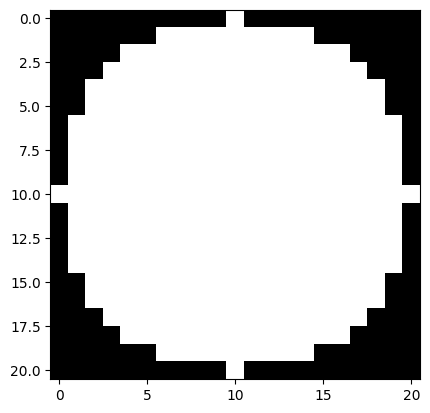

In [9]:
# Parameters
color = (255, 255, 255)   # white (BGR)
radius = 10
size = 21

# Create black canvas
canvas = np.zeros((size, size, 3), dtype=np.uint8)

# Center of the canvas
center = (size // 2, size // 2)

# Draw filled circle
cv2.circle(
    img=canvas,
    center=center,
    radius=radius,
    color=color,
    thickness=-1  # filled circle
)

# tmpl_gray = cv2.cvtColor(tmpl_bgr, cv2.COLOR_BGR2GRAY) 
# _, tmpl_mask = cv2.threshold(tmpl_gray, 1, 255, cv2.THRESH_BINARY)

# Display using matplotlib (convert BGR → RGB)
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))

In [10]:
cv2.imwrite("circle_template.png", canvas)

True

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('simulation_tracking.mp4', fourcc, 15.0, (frame_width, frame_height))

VIDEO_PATH = "simulation_detection.mp4"   # or 0 for webcam
METHOD1 = cv2.TM_CCOEFF_NORMED
METHOD2 = cv2.TM_CCORR_NORMED

TEMPLATE_SIZE = 30
MASK_RADIUS = 30
SEARCH_RADIUS = 15

NEW_MIN_SCORE = 0.5
TRACK_MIN_SCORE = 0.5

EDGE_ONEHOT_PEAK = 0.999999
EDGE_ONEHOT_ZERO = 1e-6
MAX_NEW_PER_FRAME = 5


# ----------------------------
# Helpers
# ----------------------------
def make_vanilla_circle_template(size=31, radius=15, color_bgr=(255, 255, 255)):
    tmpl = np.zeros((size, size, 3), dtype=np.uint8)
    cv2.circle(tmpl, (size//2, size//2), radius, color_bgr, thickness=-1)
    return tmpl

def extract_patch_with_padding(frame_bgr, cx, cy, size):
    h, w = frame_bgr.shape[:2]
    half = size // 2
    x0 = int(round(cx - half))
    y0 = int(round(cy - half))
    x1 = x0 + size
    y1 = y0 + size

    patch = np.zeros((size, size, 3), dtype=frame_bgr.dtype)

    sx0 = max(0, x0); sy0 = max(0, y0)
    sx1 = min(w, x1); sy1 = min(h, y1)

    dx0 = sx0 - x0; dy0 = sy0 - y0
    dx1 = dx0 + (sx1 - sx0); dy1 = dy0 + (sy1 - sy0)

    if sx1 > sx0 and sy1 > sy0:
        patch[dy0:dy1, dx0:dx1] = frame_bgr[sy0:sy1, sx0:sx1]

    return patch

def extract_particle_only_template(frame_bgr, cx, cy, size, radius):
    patch = extract_patch_with_padding(frame_bgr, cx, cy, size)
    mask = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(mask, (size // 2, size // 2), int(radius), 255, thickness=-1)
    outp = patch.copy()
    outp[mask == 0] = (0, 0, 0)
    return outp

def near_edge(cx, cy, w, h, r=11):
    return (cx < r) or (cy < r) or (cx > (w - 1 - r)) or (cy > (h - 1 - r))

def local_circle_template_match(frame_bgr, tmpl_bgr, prev_cx, prev_cy, search_r):
    th, tw = tmpl_bgr.shape[:2]
    h, w = frame_bgr.shape[:2]

    x0 = int(round(prev_cx - search_r - tw / 2))
    y0 = int(round(prev_cy - search_r - th / 2))
    x1 = int(round(prev_cx + search_r + tw / 2))
    y1 = int(round(prev_cy + search_r + th / 2))

    x0c, y0c = max(0, x0), max(0, y0)
    x1c, y1c = min(w, x1), min(h, y1)

    roi = frame_bgr[y0c:y1c, x0c:x1c]
    if roi.shape[0] < th or roi.shape[1] < tw:
        return None, None, None, None

    tmpl_gray = cv2.cvtColor(tmpl_bgr, cv2.COLOR_BGR2GRAY) 
    _, tmpl_mask = cv2.threshold(tmpl_gray, 4, 255, cv2.THRESH_BINARY)   
    res = cv2.matchTemplate(roi, tmpl_bgr, METHOD2, mask=tmpl_mask)

    rh, rw = res.shape[:2]
    xs = (np.arange(rw) + x0c) + tw / 2.0
    ys = (np.arange(rh) + y0c) + th / 2.0
    X, Y = np.meshgrid(xs, ys)
    mask = ((X - prev_cx)**2 + (Y - prev_cy)**2) <= (search_r**2)

    res_masked = res.copy()
    res_masked[~mask] = -1.0
    _, max_val, _, max_loc = cv2.minMaxLoc(res_masked)

    top_left = (x0c + max_loc[0], y0c + max_loc[1])
    new_cx = top_left[0] + tw / 2.0
    new_cy = top_left[1] + th / 2.0

    res_in_circle = res.copy()
    res_in_circle[~mask] = 0.0
    return new_cx, new_cy, max_val, res_in_circle

def mask_circle(img_bgr, cx, cy, radius):
    cv2.circle(img_bgr, (int(round(cx)), int(round(cy))), int(radius), -1, thickness=-1)


# ----------------------------
# Tracker state
# ----------------------------
class Track:
    def __init__(self, tid, cx, cy, tmpl_bgr):
        self.tid = tid
        self.cx = float(cx)
        self.cy = float(cy)
        self.tmpl = tmpl_bgr          # fixed template from FIRST detection
        self.last_score = 1.0
        self.fully_formed = False


# ----------------------------
# Main
# ----------------------------
cap = cv2.VideoCapture(VIDEO_PATH)
vanilla_tmpl = make_vanilla_circle_template(size=30, radius=15, color_bgr=(255, 255, 255))

tracks = {}
free_ids = []   # LIFO from previous frames
next_id = 1

while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_bgr = frame
    h, w = frame_bgr.shape[:2]

    dead_ids = []
    recycled_this_frame = []

    for tid, tr in list(tracks.items()):
        old_cx, old_cy = tr.cx, tr.cy

        if near_edge(old_cx, old_cy, w, h, r=MASK_RADIUS):
            dead_ids.append(tid)
            continue

        new_cx, new_cy, score, _ = local_circle_template_match(
            frame_bgr, tr.tmpl, tr.cx, tr.cy, SEARCH_RADIUS
        )

        if score is None:
            dead_ids.append(tid)
            continue

        if near_edge(new_cx, new_cy, w, h, r=MASK_RADIUS):
            dead_ids.append(tid)
            continue

        tr.cx, tr.cy = new_cx, new_cy
        tr.last_score = float(score)
        # NOTE: no template refresh (fixed template per particle)
        if score < TRACK_MIN_SCORE:
            dead_ids.append(tid)

    for tid, tr in tracks.items():
        tr.fully_formed = tr.last_score >= TRACK_MIN_SCORE

    masked = frame_bgr.copy()
    for tid, tr in tracks.items():
        mask_circle(masked, tr.cx, tr.cy, MASK_RADIUS)

    for tid in dead_ids:
        if tid in tracks:
            del tracks[tid]
            recycled_this_frame.append(tid)

    # ------------------------------------------------------------
    # B) Mask fully-formed tracks for NEW detection
    # ------------------------------------------------------------


    # ------------------------------------------------------------
    # C) NEW detection (vanilla template) + init template
    # ------------------------------------------------------------
# ------------------------------------------------------------
    # C) NEW detection (vanilla template) + init template
    # ------------------------------------------------------------
    for _ in range(MAX_NEW_PER_FRAME):
        res = cv2.matchTemplate(masked, vanilla_tmpl, METHOD1)
        _, max_val, _, max_loc = cv2.minMaxLoc(res)

        if max_val < NEW_MIN_SCORE:
            continue

        top_left = max_loc
        cx = top_left[0] + vanilla_tmpl.shape[1] / 2.0
        cy = top_left[1] + vanilla_tmpl.shape[0] / 2.0

        if near_edge(cx, cy, w, h, r=MASK_RADIUS):
            mask_circle(masked, cx, cy, MASK_RADIUS)
            continue

        # ========================================================
        # CRITICAL FIX: Coordinate Distance Check
        # ========================================================
        # Even if the mask failed, this math will catch the duplicate.
        # We calculate the distance from this "new" spot to EVERY existing tracker.
        
        is_duplicate_of_existing = False
        for tid, tr in tracks.items():
            # Pythagorean theorem distance
            dist = ((cx - tr.cx)**2 + (cy - tr.cy)**2)**0.5
            
            # If the new hit is within 15 pixels (adjust as needed) of an old one
            if dist < 15.0:  
                is_duplicate_of_existing = True
                break
        
        if is_duplicate_of_existing:
            # It's a ghost! Paint over it so we don't find it again this frame
            mask_circle(masked, cx, cy, MASK_RADIUS)
            continue
        # ========================================================

        if recycled_this_frame:
            tid = recycled_this_frame.pop()
        elif free_ids:
            tid = free_ids.pop()
        else:
            tid = next_id
            next_id += 1

        tmpl0 = extract_particle_only_template(frame_bgr, cx, cy, TEMPLATE_SIZE, MASK_RADIUS)
        tracks[tid] = Track(tid, cx, cy, tmpl0)

        mask_circle(masked, cx, cy, MASK_RADIUS)

    while recycled_this_frame:
        free_ids.append(recycled_this_frame.pop())

    # ------------------------------------------------------------
    # D) Draw + write
    # ------------------------------------------------------------
    for tid, tr in tracks.items():
        half = TEMPLATE_SIZE // 2
        x1 = int(round(tr.cx - half))
        y1 = int(round(tr.cy - half))
        x2 = x1 + TEMPLATE_SIZE
        y2 = y1 + TEMPLATE_SIZE
        cv2.rectangle(frame_bgr, (x1-2, y1-2), (x2+2, y2+2), (0, 255, 0), 1)
        cv2.putText(frame_bgr, f"#{tid}", (x1, y1 - 7),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)

    cv2.imshow("Particle tracking (rolling template, BGR)", frame_bgr)
    out.write(frame_bgr)

    if cv2.waitKey(10) & 0xFF == 27:
        break

out.release()
cap.release()
cv2.destroyAllWindows()
